In [22]:
import os
import sys
import h5py
import yaml
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

from matplotlib import pyplot as plt
import colorsys
import matplotlib
from matplotlib.lines import Line2D
from matplotlib.font_manager import FontProperties

labelfont = FontProperties()
labelfont.set_family('serif')
labelfont.set_name('Times New Roman')
labelfont.set_size(14)

axislabelfont = FontProperties()
axislabelfont.set_family('serif')
axislabelfont.set_name('Times New Roman')
axislabelfont.set_size(22)

tickfont = FontProperties()
tickfont.set_family('serif')
tickfont.set_name('Times New Roman')
tickfont.set_size(16)

axisfontsize = 16
labelfontsize = 16

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.default"] = "rm"
plt.rcParams['text.usetex'] = True

In [23]:
from snnae import SNNAE, AE
from data_utils import get_cms_data, get_top_data
from dataset import cdataset

# CMS data

In [24]:
data = get_cms_data( num_events_per_class=50000, add_one_hot=False, drop_angles=True, pt_norm_method="max_per_category", pt_offset=0.1 )

sm data shape before any preprocessing: (50000, 19, 3)
sm data shape after dropping angles: (50000, 19, 1)
sm data shape after flattening: (50000, 19)


In [25]:
sm_dataset = cdataset( data["sm"], labels=np.zeros( data["sm"].shape[0] ) )
h0_dataset = cdataset( np.concatenate( [data["sm"],data["h0"]], axis=0 ), labels=np.concatenate( [np.zeros(data["sm"].shape[0]),np.ones(data["h0"].shape[0])] ) )
hc_dataset = cdataset( np.concatenate( [data["sm"],data["hc"]], axis=0 ), labels=np.concatenate( [np.zeros(data["sm"].shape[0]),np.ones(data["hc"].shape[0])] ) )
a4l_dataset = cdataset( np.concatenate( [data["sm"],data["a4l"]], axis=0 ), labels=np.concatenate( [np.zeros(data["sm"].shape[0]),np.ones(data["a4l"].shape[0])] ) )
lq_dataset = cdataset( np.concatenate( [data["sm"],data["lq"]], axis=0 ), labels=np.concatenate( [np.zeros(data["sm"].shape[0]),np.ones(data["lq"].shape[0])] ) )

batch_size = 1000

train_loader = DataLoader( sm_dataset, batch_size=batch_size, shuffle=True, drop_last=True )
test_loader_h0 = DataLoader( h0_dataset, batch_size=batch_size, shuffle=True, drop_last=True )
test_loader_hc = DataLoader( hc_dataset, batch_size=batch_size, shuffle=True, drop_last=True )
test_loader_a4l = DataLoader( a4l_dataset, batch_size=batch_size, shuffle=True, drop_last=True )
test_loader_lq = DataLoader( lq_dataset, batch_size=batch_size, shuffle=True, drop_last=True )

In [26]:
def full_dnn_run( run_name, input_dim, layers, latent_dim, lr, num_epochs, quant, qpr, num_nets ):
    os.mkdir(run_name)
    save_args = {    "input_dim":input_dim,
                "layers":layers,
                "latent_dim":latent_dim,
                "lr":lr,
                "num_epochs":num_epochs,
                "quant":quant,
                "qpr": qpr,
                "num_nets":num_nets
           }
    with open( run_name + '/args.yaml', 'w' ) as f:
        yaml.dump(save_args, f, default_flow_style=False)
    run_args = {    "input_dim":input_dim,
                "layers":layers,
                "latent_dim":latent_dim,
                "lr":lr,
                "quant":quant,
                "qpr": qpr,
           }
    labels = {"A4l":'$A_{4l}$',"h0":'$h_0$',"hc":'$h_+$',"LQ":'$\phi$'}
    colors = {"A4l":'b',"h0":'r',"hc":'g',"LQ":'m'}
    sig_loaders = {"A4l":test_loader_a4l,"h0":test_loader_h0,"hc":test_loader_hc,"LQ":test_loader_lq}
    all_tpr = {"A4l":[],"h0":[],"hc":[],"LQ":[]}
    all_inv_fpr = {"A4l":[],"h0":[],"hc":[],"LQ":[]}
    all_auc = {"A4l":[],"h0":[],"hc":[],"LQ":[]}
    auc_mean = {"A4l":[],"h0":[],"hc":[],"LQ":[]}
    auc_std = {"A4l":[],"h0":[],"hc":[],"LQ":[]}
    all_inv_fpr_at_0_3 = {"A4l":[],"h0":[],"hc":[],"LQ":[]}
    inv_fpr_at_0_3_mean = {"A4l":[],"h0":[],"hc":[],"LQ":[]}
    inv_fpr_at_0_3_std = {"A4l":[],"h0":[],"hc":[],"LQ":[]}
    final_losses = []
    for i in range(num_nets):
        print( f'-- NET {i} --') 
        net = AE( **run_args )
        net.train_model( train_loader, num_epochs=num_epochs )
        for sig in ["A4l","h0","hc","LQ"]:
            tpr, inv_fpr, roc_auc, inv_fpr_at_0_3 = net.eval_model(sig_loaders[sig])
            all_tpr[sig].append(tpr)
            all_inv_fpr[sig].append(inv_fpr)
            all_auc[sig].append(roc_auc)
            all_inv_fpr_at_0_3[sig].append(inv_fpr_at_0_3)
        net.plot_loss_epochs( log_yscale=True, savefig=run_name+f"/net_{i}_loss_curve.png", show_plots=True)
        final_losses.append( net.loss_hist[-1] )
        with open( run_name+f'/net_{i}_losses.txt', 'w' ) as f:
            f.write( str([ i for i in net.loss_hist ]) )
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.set_box_aspect(1)
    target_tprs = np.linspace(0, 1, 100)
    for sig in ["A4l","h0","hc","LQ"]:
        collected_inv_fprs = []
        auc_mean[sig] = np.mean(all_auc[sig])
        auc_std[sig] = np.std(all_auc[sig])
        inv_fpr_at_0_3_mean[sig] = np.mean(all_inv_fpr_at_0_3[sig])
        inv_fpr_at_0_3_std[sig] = np.std(all_inv_fpr_at_0_3[sig])
        for target in target_tprs:
            inv_fprs_at_target = []
            for tpr, inv_fpr in zip(all_tpr[sig], all_inv_fpr[sig]):
                if len(tpr) == 0:
                    continue
                idx = np.argmin(np.abs(tpr - target))  # Index of closest TPR
                inv_fprs_at_target.append(inv_fpr[idx])
            collected_inv_fprs.append(inv_fprs_at_target)
        collected_inv_fprs = np.array(collected_inv_fprs, dtype=float)
        mean_inv_fpr = np.mean(collected_inv_fprs, axis=1)
        std_inv_fpr = np.std(collected_inv_fprs, axis=1)
        ax.plot(target_tprs, mean_inv_fpr, color=colors[sig], lw=2, label=f'{labels[sig]}')
        ax.fill_between(target_tprs, mean_inv_fpr - std_inv_fpr, mean_inv_fpr + std_inv_fpr, color=colors[sig], alpha=0.3)
    ax.plot([1-i/10000 for i in range(10000)], [1/(1-i/10000) for i in range(10000)], color='gray', linestyle='--')
    ax.set_yscale('log')
    ax.set_xlabel(r'$\epsilon_s$', fontsize=16)
    ax.set_ylabel(r'$\epsilon_b^{-1}$', fontsize=16)
    ax.set_ylim(1,1000)
    ax.tick_params(labelsize=14)
    ax.legend(loc="upper right", title='DNN-AE', fontsize=14, title_fontsize=14)
    ax.grid(True)
    mean_final_loss = np.mean( final_losses )
    std_final_loss = np.std( final_losses )
    for sig in ["A4l","h0","hc","LQ"]:
        print('---')
        print(sig)
        print(f"AUC: {auc_mean[sig]} +/- {auc_std[sig]}")
        print(f"inv_fpr_at_0_3: {inv_fpr_at_0_3_mean[sig]} +/- {inv_fpr_at_0_3_std[sig]}")
        print('---')
    fig.savefig( run_name+'/roc.png', dpi=400, bbox_inches="tight" )
    with open( run_name+'/stats.txt', 'w' ) as f:
        for sig in ["A4l","h0","hc","LQ"]:
            f.write( sig + f' - AUC: {auc_mean[sig]} +- {auc_std[sig]}, inv_fpr_0.3: {inv_fpr_at_0_3_mean[sig]} +- {inv_fpr_at_0_3_std[sig]}' + '\n' )
        f.write('\n')
        f.write(f'final loss:  {mean_final_loss} +- {std_final_loss}')
    fig.show()

-- NET 0 --
ModuleList(
  (0): Linear(in_features=19, out_features=24, bias=True)
  (1): ReLU()
  (2): Linear(in_features=24, out_features=12, bias=True)
  (3): ReLU()
  (4): Linear(in_features=12, out_features=4, bias=True)
)
ModuleList(
  (0): Linear(in_features=4, out_features=12, bias=True)
  (1): ReLU()
  (2): Linear(in_features=12, out_features=24, bias=True)
  (3): ReLU()
  (4): Linear(in_features=24, out_features=19, bias=True)
)


/home/b/Physics/snn-anomalies/snnae.py:853: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr
/home/b/Physics/snn-anomalies/snnae.py:853: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr
/home/b/Physics/snn-anomalies/snnae.py:853: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr
/home/b/Physics/snn-anomalies/snnae.py:853: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr


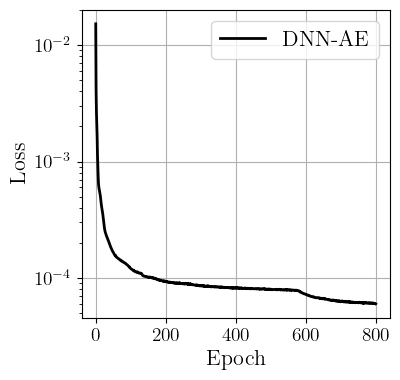

-- NET 1 --
ModuleList(
  (0): Linear(in_features=19, out_features=24, bias=True)
  (1): ReLU()
  (2): Linear(in_features=24, out_features=12, bias=True)
  (3): ReLU()
  (4): Linear(in_features=12, out_features=4, bias=True)
)
ModuleList(
  (0): Linear(in_features=4, out_features=12, bias=True)
  (1): ReLU()
  (2): Linear(in_features=12, out_features=24, bias=True)
  (3): ReLU()
  (4): Linear(in_features=24, out_features=19, bias=True)
)


/home/b/Physics/snn-anomalies/snnae.py:853: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr
/home/b/Physics/snn-anomalies/snnae.py:853: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr
/home/b/Physics/snn-anomalies/snnae.py:853: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr
/home/b/Physics/snn-anomalies/snnae.py:853: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr


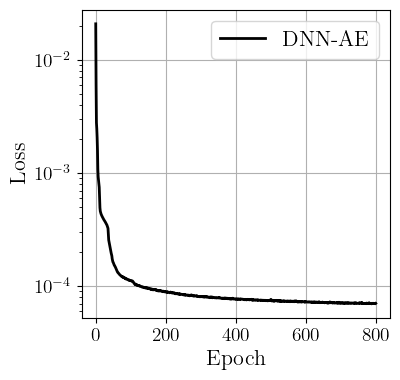

-- NET 2 --
ModuleList(
  (0): Linear(in_features=19, out_features=24, bias=True)
  (1): ReLU()
  (2): Linear(in_features=24, out_features=12, bias=True)
  (3): ReLU()
  (4): Linear(in_features=12, out_features=4, bias=True)
)
ModuleList(
  (0): Linear(in_features=4, out_features=12, bias=True)
  (1): ReLU()
  (2): Linear(in_features=12, out_features=24, bias=True)
  (3): ReLU()
  (4): Linear(in_features=24, out_features=19, bias=True)
)


/home/b/Physics/snn-anomalies/snnae.py:853: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr
/home/b/Physics/snn-anomalies/snnae.py:853: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr
/home/b/Physics/snn-anomalies/snnae.py:853: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr
/home/b/Physics/snn-anomalies/snnae.py:853: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr


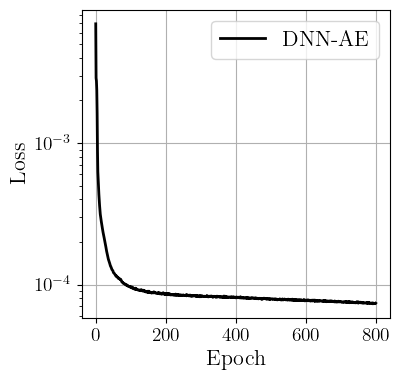

-- NET 3 --
ModuleList(
  (0): Linear(in_features=19, out_features=24, bias=True)
  (1): ReLU()
  (2): Linear(in_features=24, out_features=12, bias=True)
  (3): ReLU()
  (4): Linear(in_features=12, out_features=4, bias=True)
)
ModuleList(
  (0): Linear(in_features=4, out_features=12, bias=True)
  (1): ReLU()
  (2): Linear(in_features=12, out_features=24, bias=True)
  (3): ReLU()
  (4): Linear(in_features=24, out_features=19, bias=True)
)


/home/b/Physics/snn-anomalies/snnae.py:853: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr
/home/b/Physics/snn-anomalies/snnae.py:853: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr
/home/b/Physics/snn-anomalies/snnae.py:853: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr
/home/b/Physics/snn-anomalies/snnae.py:853: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr


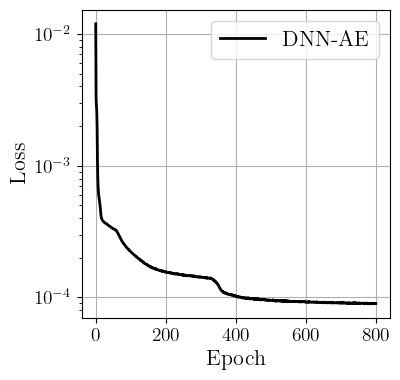

-- NET 4 --
ModuleList(
  (0): Linear(in_features=19, out_features=24, bias=True)
  (1): ReLU()
  (2): Linear(in_features=24, out_features=12, bias=True)
  (3): ReLU()
  (4): Linear(in_features=12, out_features=4, bias=True)
)
ModuleList(
  (0): Linear(in_features=4, out_features=12, bias=True)
  (1): ReLU()
  (2): Linear(in_features=12, out_features=24, bias=True)
  (3): ReLU()
  (4): Linear(in_features=24, out_features=19, bias=True)
)


/home/b/Physics/snn-anomalies/snnae.py:853: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr
/home/b/Physics/snn-anomalies/snnae.py:853: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr
/home/b/Physics/snn-anomalies/snnae.py:853: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr
/home/b/Physics/snn-anomalies/snnae.py:853: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr


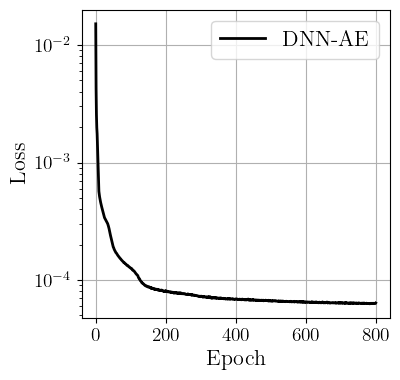

/home/b/venvs/ml/lib/python3.10/site-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


---
A4l
AUC: 0.8823404182799999 +/- 0.012500027004702043
inv_fpr_at_0_3: 335.03449628957014 +/- 96.96434973125038
---
---
h0
AUC: 0.7125964016399999 +/- 0.009169035385076537
inv_fpr_at_0_3: 20.62085509672639 +/- 2.2364756502404277
---
---
hc
AUC: 0.8997601697200001 +/- 0.01074764268567427
inv_fpr_at_0_3: 115.24120329894458 +/- 11.909494434881452
---
---
LQ
AUC: 0.8398874749199999 +/- 0.01065800533995784
inv_fpr_at_0_3: 32.52545314246491 +/- 3.2819115806188814
---


/tmp/ipykernel_4305/2840373071.py:91: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


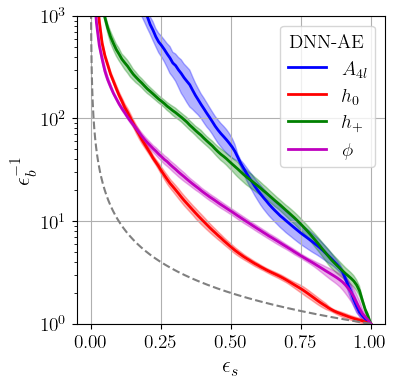

In [27]:
full_dnn_run( 'results/DNNAE-24-12-4-LR001-50k', data["sm"].shape[-1], [24,12], 4, 0.001, 800, False, 8, 5 )